In [384]:
from sympy.core.random import sample
!pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Razumevanje Podataka

### Učitavanje podataka

In [385]:
import pandas as pd
df = pd.read_csv("hf://datasets/sairamn/gcp-cloud-billing-cost/data.csv")

### Opisivanje podataka

Dataset koji smo izabrali sadrži sledeće atribute <br>
Resource ID - id resursa <br>
Service Name - Naziv GCP servisa <br>
Usage Quantity - Količina utrošenog resursa <br>
Usage Unit - Jedinica utrošenog resursa <br>
Region / Zone - Regija u kojoj se nalazi resurs <br>
CPU Utilization - Iskorišćenost procesora izražena u procentima <br>
Memory Utilization - Utoršenost memorije <br>
Network Inbound Data (Bytes) - Količina bajtova koju servis šalje preko mreže<br>
Network Outbound Data (Bytes) - Količina bajtova koju servis prima preko mreže<br>
Usage Start Date - Početak korišćenja <br>
Usage End Date - Kraj korišćenja <br>
Cost per Quanitity - Jedinična cena resursa <br>
Unrounded Cost - Nezaukružena cena <br>
Rounded Cost - Zaokružena cena <br>


Dataset ne poseduje NA vrednosti tako da nije potrebno vršiti čišćenje opservacija

In [386]:
df.shape

(124275, 15)

In [387]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124275 entries, 0 to 124274
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Resource ID                    124275 non-null  str    
 1   Service Name                   124275 non-null  str    
 2   Usage Quantity                 124275 non-null  float64
 3   Usage Unit                     124275 non-null  str    
 4   Region / Zone                  124275 non-null  str    
 5   CPU Utilization (%)            124275 non-null  float64
 6   Memory Utilization (%)         124275 non-null  float64
 7   Network Inbound Data (Bytes)   124275 non-null  float64
 8   Network Outbound Data (Bytes)  124275 non-null  float64
 9   Usage Start Date               124275 non-null  str    
 10  Usage End Date                 124275 non-null  str    
 11  Cost per Quantity ($)          124275 non-null  float64
 12  Unrounded Cost ($)             124275 non

In [388]:
df.isna().sum().sum()

np.int64(0)

Cilj ovog modela je da uspesno predvidi troskove koriscenja cloud resursa za vremenski period od N sati. Konkretno nasa ideja je bila da se kreira model koji omogucava predvidjanje troskova cloud resursa na osnovu tipa servisa, količine iskorišćenosti i metrika performansi

### Provera kvaliteta podataka i prirode promenljivi

Posmatranjem kategoričkih obeležja Service Name i Usage Unit uočavamo da svakom tipu servisa odgovara tačno jedna jedinica utroška (npr. Compute Engine uvek koristi Hours, Cloud Storage uvek GB). Zaključujemo da promenljiva Usage Unit ne donosi dodatnu informaciju modelu i izbacujemo je iz dataset-a

In [389]:
print(df.groupby("Service Name")["Usage Unit"].unique())

Service Name
App Engine              [Hours]
Artifact Registry          [GB]
BigQuery             [Requests]
Cloud Armor          [Requests]
Cloud Build          [Requests]
Cloud CDN            [Requests]
Cloud Dataflow          [Hours]
Cloud Dataproc          [Hours]
Cloud Filestore            [GB]
Cloud Functions      [Requests]
Cloud Logging              [GB]
Cloud Memorystore          [GB]
Cloud Monitoring           [GB]
Cloud Pub/Sub        [Requests]
Cloud Run            [Requests]
Cloud SQL               [Hours]
Cloud Scheduler      [Requests]
Cloud Spanner           [Hours]
Cloud Storage              [GB]
Cloud Tasks          [Requests]
Compute Engine          [Hours]
Dialogflow           [Requests]
Secret Manager       [Requests]
Name: Usage Unit, dtype: object


Isto važi i za promenljivu Resource ID, koja jedinstveno identifikuje resurs. Ova promenljiva neće dodati ikakvu značajnu informaciju modelu, pa je izbacujemo iz dataset-a

In [390]:
df.drop(columns=['Resource ID','Usage Unit'],inplace=True)

Nakon toga izdvojicemo iz promenljivih tipa datum trajanje korišćenja resursa

In [391]:
df['Usage Start Date'] = pd.to_datetime(df['Usage Start Date'],errors='raise')
df['Usage End Date'] = pd.to_datetime(df['Usage End Date'],errors='raise')

df['duration_hours'] = (df['Usage End Date'] - df['Usage Start Date']).dt.total_seconds() / 3600
df.drop(columns=['Usage Start Date', 'Usage End Date'],inplace=True)

Nakon toga prikazujemo jos jednom tipove promenljivih

In [392]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124275 entries, 0 to 124274
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Service Name                   124275 non-null  str    
 1   Usage Quantity                 124275 non-null  float64
 2   Region / Zone                  124275 non-null  str    
 3   CPU Utilization (%)            124275 non-null  float64
 4   Memory Utilization (%)         124275 non-null  float64
 5   Network Inbound Data (Bytes)   124275 non-null  float64
 6   Network Outbound Data (Bytes)  124275 non-null  float64
 7   Cost per Quantity ($)          124275 non-null  float64
 8   Unrounded Cost ($)             124275 non-null  float64
 9   Rounded Cost ($)               124275 non-null  int64  
 10  Total Cost (INR)               124275 non-null  int64  
 11  duration_hours                 124275 non-null  float64
dtypes: float64(8), int64(2), str(2)
memory us

In [393]:
#df.drop(columns='Cost per Quantity ($)',inplace=True)

In [394]:
num_cols = ['Cost per Quantity ($)','Usage Quantity','CPU Utilization (%)','Memory Utilization (%)','Network Inbound Data (Bytes)','Network Outbound Data (Bytes)', 'Unrounded Cost ($)','duration_hours','Rounded Cost ($)','Total Cost (INR)']

Za svaki slucaj cemo proveriti da li postoje i izbaciti instance cije numericke vrednosti ne bi trebale da imaju negativne vrednosti, kroz manuelnu proveru smo ustanovili da postoji odredjeni broj instanci koje imaju negativni trosak (verovatno zbog gcp kredita)

In [395]:
positive_instances = (df[num_cols] >= 0).all(axis=1)
df = df[positive_instances].reset_index(drop=True)

## Provera multikolinearnosti

In [396]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_heatmap(df, columns):
    corr = df[columns].corr()
    plt.figure(figsize=(10, 10))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Korelaciona matrica")
    plt.tight_layout()
    plt.show()

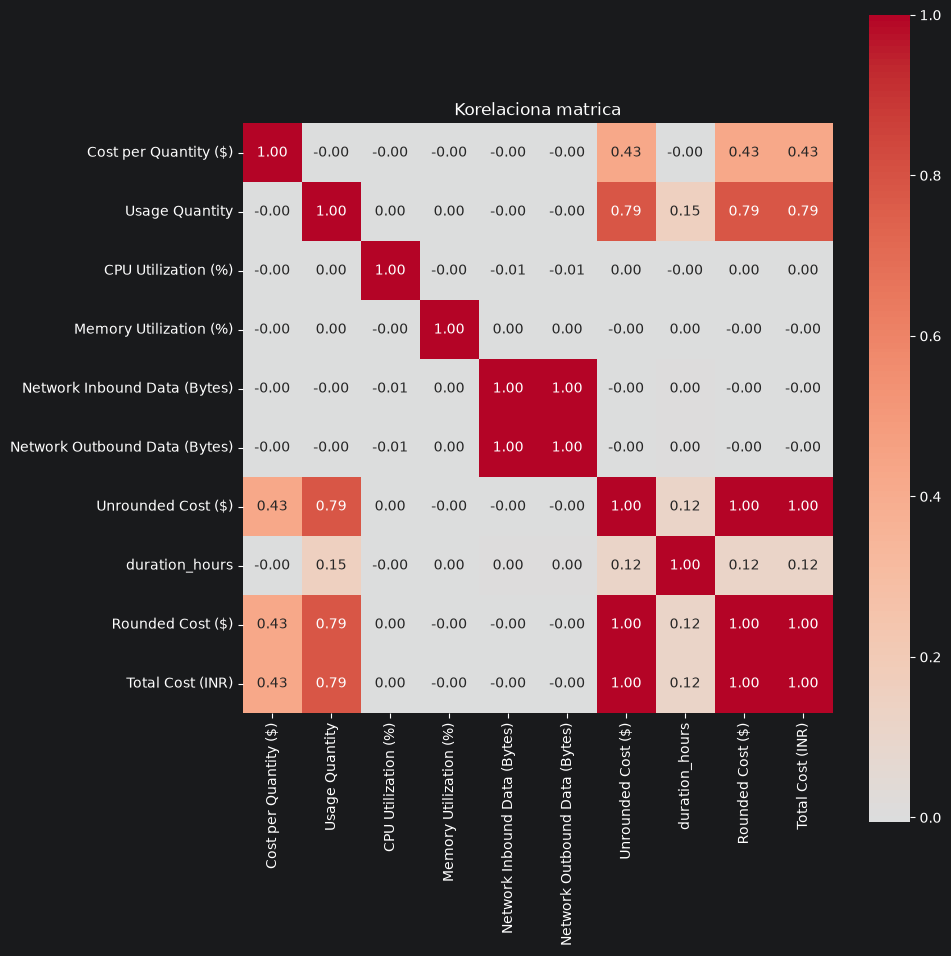

In [397]:
plot_correlation_heatmap(df,num_cols)

Na osnovu korelacione matrice zakljucujemo sledeće obrasce: <br>
- Rounded Cost, Unrounded Cost i Total Cost imaju korelaciju 1, što je i logično, sobzirom da su u izvedene jedna iz druge, izbacićemo dve od tri
- Network Inbound i Network Outbound imaju korelaciju 1, odstranićemo jedno obeležje pošto oba objašnjavaju isti deo varijanse izlazne promenljive
- Obeležja Usage Quantity i Cost per Quantity su umereno/visoko korelisane sa izlaznim obeležjem, na osnovu više pokušaja sprovođenja ove analize, ustanovili smo da model nije u sposobnosti da opiše veliki procenat varijabiliteta izlaznog obeležja bez ova dva atributa. Takodje logički gledano ova dva atributa, doprinose veliki deo procene troškova cloud resursa

In [398]:
df.drop(columns=['Network Inbound Data (Bytes)','Total Cost (INR)','Rounded Cost ($)'], inplace=True)
num_cols.remove('Network Inbound Data (Bytes)')
num_cols.remove('Total Cost (INR)')
num_cols.remove('Rounded Cost ($)')

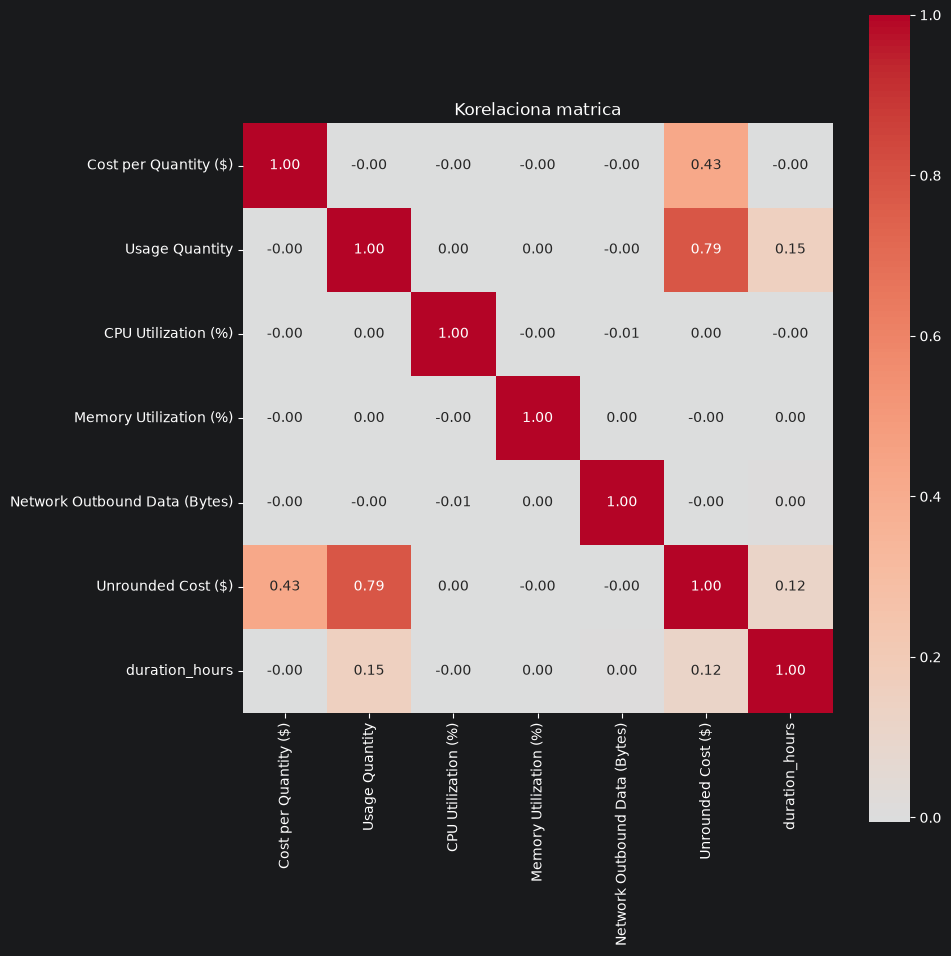

In [399]:
plot_correlation_heatmap(df,num_cols)

### Testiranje simetricnosti raspodela

Kako bismo omogucili standardno skaliranje i ravnomerno uvazavanje gradijenata, potrebno je testirati simetricnost raspodela promenljivi i transformisati one sa asimetricnom raspodelom

In [400]:
import numpy as np
def plot_num_cols(df,columns,bins=40):
    n = len(columns)
    ncols = 3
    nrows = int(np.ceil(n/ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize= (6 * ncols, 6 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(columns):
        data = df[col].dropna()
        label = col
        axes[i].hist(data, bins=bins,color='blue',edgecolor='black', alpha=0.8)
        axes[i].set_title(label)
        axes[i].set_xlabel(label)
        axes[i].set_ylabel("broj opservacija")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

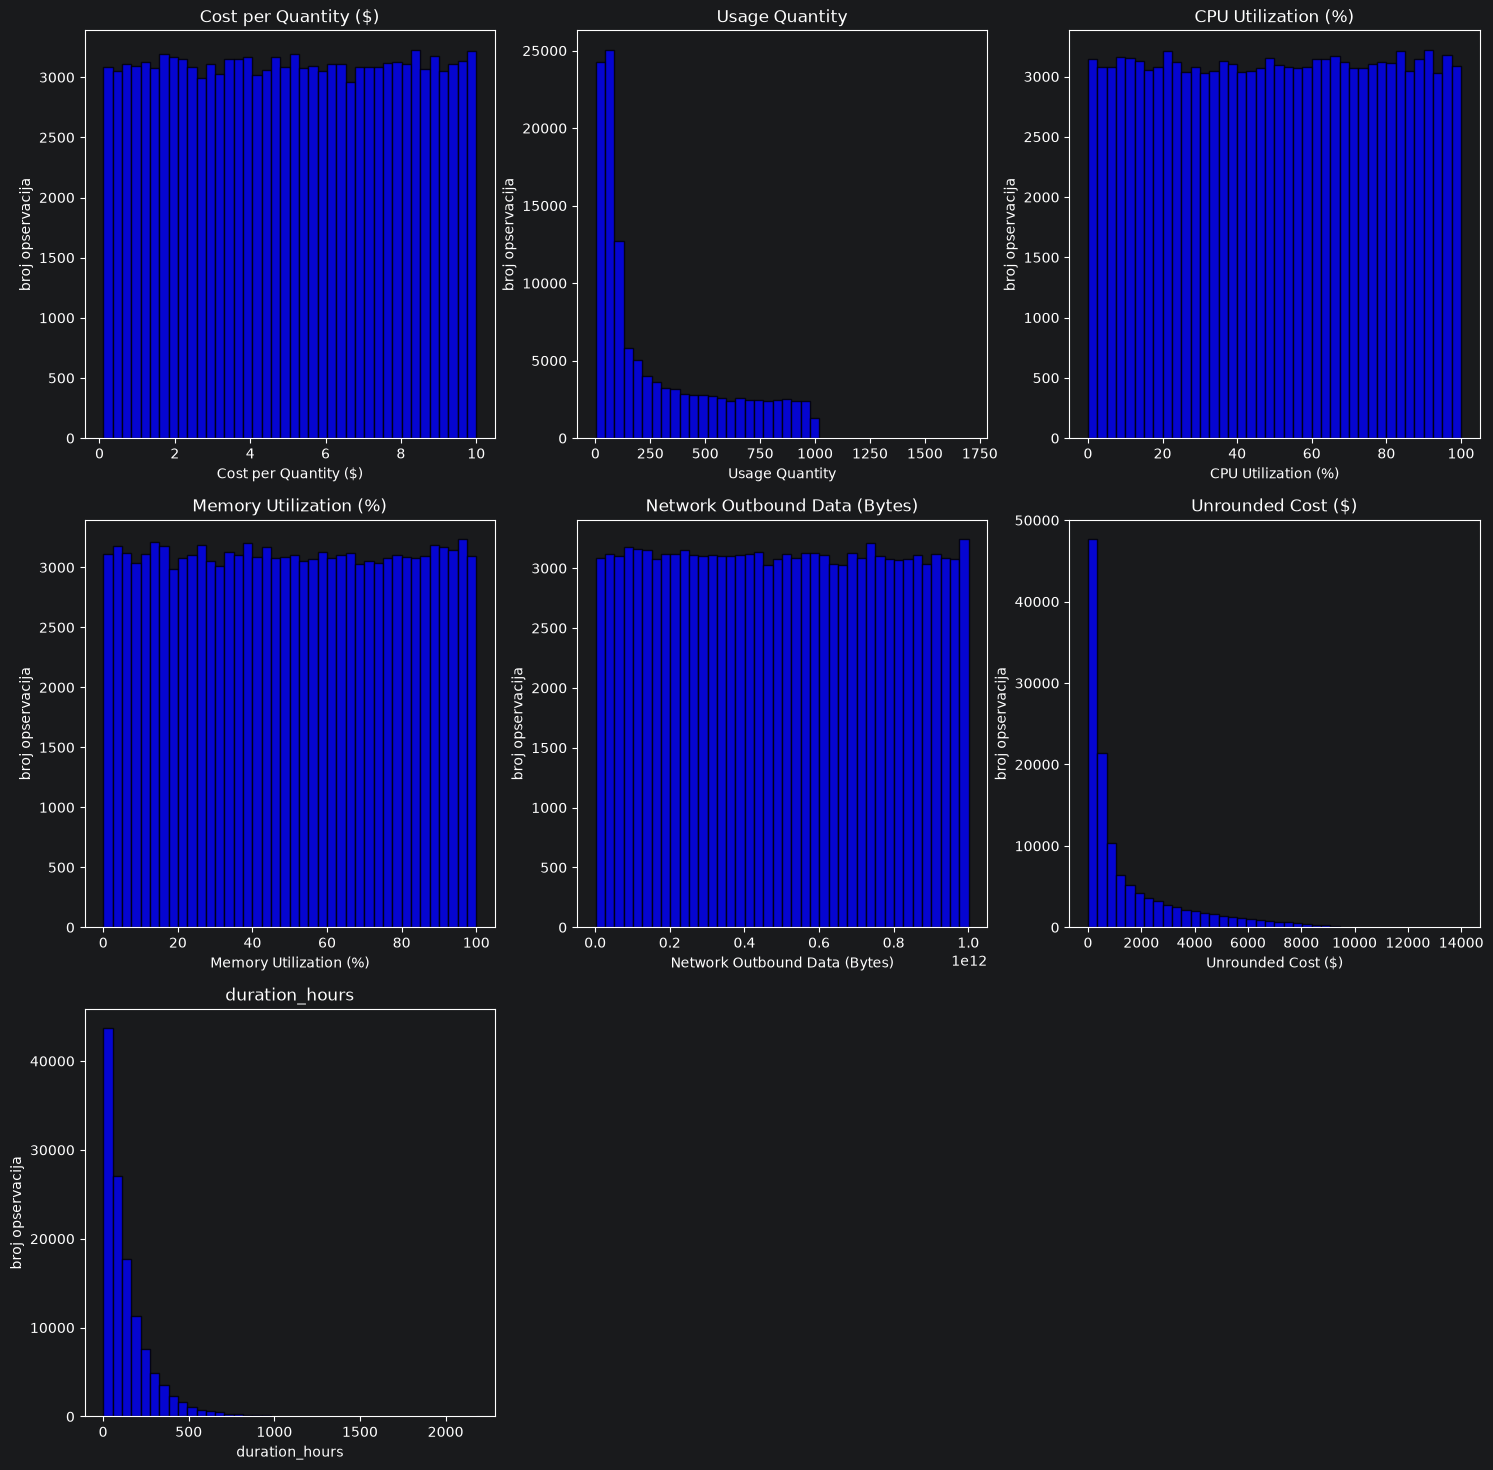

In [401]:
plot_num_cols(df,num_cols)

Vecina obelezja poseduje raspodelu pribliznu uniformnoj, sto je dobro za ravnomerne gradijente. Postoji mali broj raspodela koje su asimetricne udesno, koje mogu da poremete skaliranje

Takodje cemo uraditi test asimetricnosti kako bismo imali dodatnu potvrdu o asimetricnosti

Na osnovu datih grafikona raspodela može se zaključiti da Obelezja Unrounded Cost, Duration Hours, Usage Quantity imaju raspodelu asimetricnu udesno. Primenicemo logaritamsku tranformaciju kako bismo korigovali ove raspodele

In [402]:
from scipy.stats import skew
for col in num_cols:
    s = skew(df[col].dropna())
    print(f"{col}: skew = {s:.3f}")

Cost per Quantity ($): skew = 0.001
Usage Quantity: skew = 1.022
CPU Utilization (%): skew = -0.004
Memory Utilization (%): skew = 0.002
Network Outbound Data (Bytes): skew = 0.005
Unrounded Cost ($): skew = 1.875
duration_hours: skew = 2.708


In [403]:
df['Unrounded Cost ($)'] = np.log1p(df['Unrounded Cost ($)'])
df['duration_hours'] = np.log1p(df['duration_hours'])
df['Usage Quantity'] = np.log1p(df['Usage Quantity'])

### Graficki prikaz raspodela transformisanih kolona

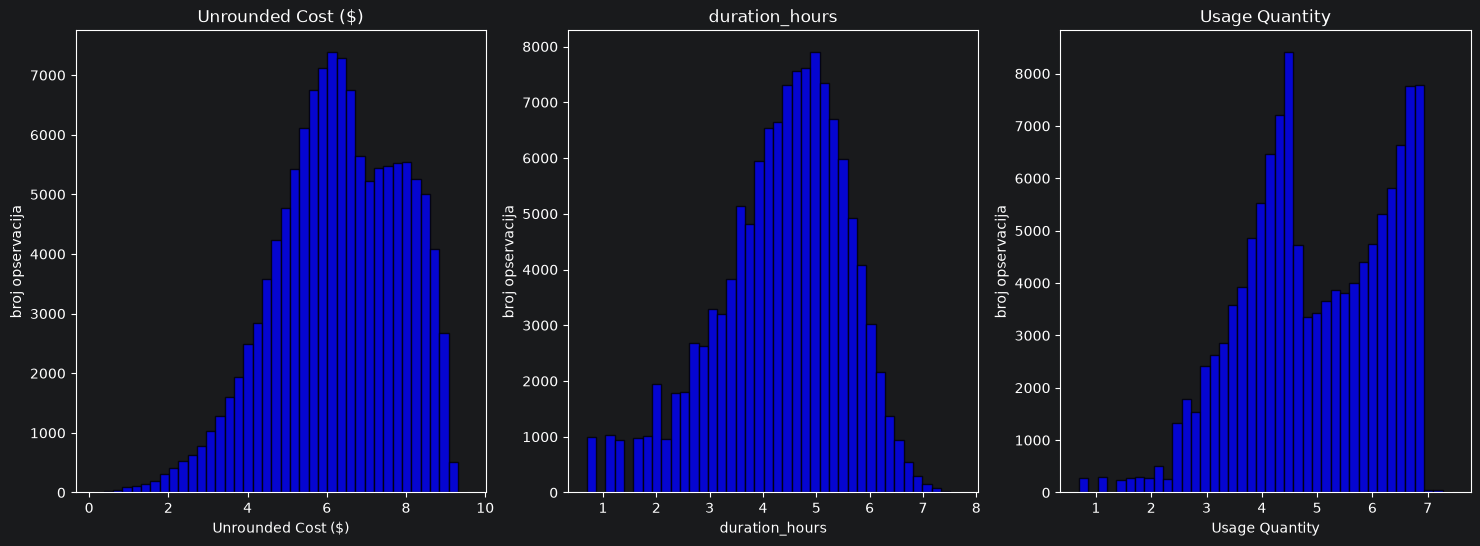

In [404]:
plot_num_cols(df,['Unrounded Cost ($)','duration_hours','Usage Quantity'])

Sada sumarne skale teze simetricnim raspodelama

In [405]:
for col in ['Unrounded Cost ($)','duration_hours','Usage Quantity']:
    s = skew(df[col].dropna())
    print(f"{col}: skew = {s:.3f}")

Unrounded Cost ($): skew = -0.394
duration_hours: skew = -0.596
Usage Quantity: skew = -0.286


Poslednje sto moramo da uradimo je konvertujemo numericke promenljive service i region u numericke, to cemo postici one-hot encoding-om

In [406]:
def one_hot_encode_col(dataframe, column):
    ohe = pd.get_dummies(dataframe[column], dtype=int)
    df_res = pd.concat([dataframe.drop(columns=column),ohe], axis=1)
    return df_res

In [407]:
df = one_hot_encode_col(df,'Service Name')
df = one_hot_encode_col(df,'Region / Zone')

In [408]:
df.sample(n = 10, random_state = 17)

,Usage Quantity,CPU Utilization (%),Memory Utilization (%),Network Outbound Data (Bytes),Cost per Quantity ($),Unrounded Cost ($),duration_hours,App Engine,Artifact Registry,BigQuery,...,Cloud Tasks,Compute Engine,Dialogflow,Secret Manager,asia-east1,asia-south1,europe-west1,us-central1,us-east1,us-west1
89924,5.730100,9.17,89.07,1.306690e+11,8.4767,7.864553,5.541264,0,0,0,...,1,0,0,0,0,0,1,0,0,0
57738,5.342334,9.43,11.88,6.157440e+11,0.7400,5.042909,5.342334,0,0,0,...,0,0,0,0,1,0,0,0,0,0
62271,4.882802,40.11,28.23,7.254920e+11,7.2807,6.861472,5.181784,0,0,0,...,0,0,0,0,0,1,0,0,0,0
98228,4.543295,18.21,61.31,5.935249e+10,8.5812,6.683426,4.543295,0,0,0,...,0,0,0,0,0,0,0,1,0,0
33495,1.098612,77.47,62.08,7.896220e+11,9.1428,2.959359,1.098612,0,0,0,...,0,0,0,0,0,0,0,0,1,0
850,4.624973,5.18,37.36,9.005960e+11,2.6205,5.582257,4.624973,1,0,0,...,0,0,0,0,0,0,1,0,0,0
25974,4.456226,60.76,87.86,5.518410e+11,3.4799,5.694924,6.161207,0,1,0,...,0,0,0,0,0,0,0,0,1,0
109838,6.118097,88.95,74.52,6.426880e+11,4.9333,7.712348,5.398163,0,0,0,...,0,0,0,0,0,1,0,0,0,0
64138,5.332719,22.84,14.71,5.757210e+11,2.4441,6.223537,5.332719,0,0,0,...,0,0,0,0,0,0,0,0,1,0
76491,4.276666,69.66,92.95,2.719520e+11,4.2868,5.721501,4.276666,1,0,0,...,0,0,0,0,0,0,0,0,1,0


In [409]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124275 entries, 0 to 124274
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Usage Quantity                 124275 non-null  float64
 1   CPU Utilization (%)            124275 non-null  float64
 2   Memory Utilization (%)         124275 non-null  float64
 3   Network Outbound Data (Bytes)  124275 non-null  float64
 4   Cost per Quantity ($)          124275 non-null  float64
 5   Unrounded Cost ($)             124275 non-null  float64
 6   duration_hours                 124275 non-null  float64
 7   App Engine                     124275 non-null  int64  
 8   Artifact Registry              124275 non-null  int64  
 9   BigQuery                       124275 non-null  int64  
 10  Cloud Armor                    124275 non-null  int64  
 11  Cloud Build                    124275 non-null  int64  
 12  Cloud CDN                      124275 non

### Skaliranje i podela podataka

Podatke delimo na trening, validacioni i test skup, a zatim standardizujemo numeričke vrednosti. Skaliranje je ključno jer izjednačava opsege svih obeležja, što omogućava stabilan i brz rad gradijentnog spusta. Podela na dva zasebna skupa van treninga je neophodna da bi se izbeglo curenje informacija: validacioni skup se koristi tokom razvoja za podešavanje hiperparametara i sprečavanje overfittinga, dok test skup ostaje netaknut do samog kraja kako bi pružio potpuno objektivnu procenu tačnosti modela na novim podacima.

In [410]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

target_col = 'Unrounded Cost ($)'
X = df.drop(columns=[target_col])
y = df[target_col].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

cols_to_scale = ['Cost per Quantity ($)','Usage Quantity','CPU Utilization (%)', 'Memory Utilization (%)', 'Network Outbound Data (Bytes)', 'duration_hours']
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), cols_to_scale)],
    remainder='passthrough'
)

X_train = preprocessor.fit_transform(X_train).astype(np.float32)
X_val = preprocessor.transform(X_val).astype(np.float32)
X_test = preprocessor.transform(X_test).astype(np.float32)

train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train.astype(np.float32)))
val_dataset = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val.astype(np.float32)))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test.astype(np.float32)))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

### Pomoćne funkcije za evaluaciju i treniranje modela

Funkcija za treniranje neuronske mreže u kojoj early stopping. Nakon svake epohe evaluiramo nove parametre u odnosu na validacioni skup i ukoliko primetimo da se greška ne smanjuje tokom N uzastopnih epoha (definisano u patience), automatski prekidamo trening i pomoću metode deepcopy vraćamo model na stanje sa najboljim težinama koje smo zabeležili pre nego što je tačnost počela da opada.

In [411]:

import copy

def train_model(
    model, 
    train_loader, 
    val_loader, 
    optimizer, 
    criterion, 
    epochs=50, 
    patience=8, 
    device="cpu"
):
    model.to(device)
    best_val_loss = float('inf')
    trigger_count = 0
    best_model_state = None
    
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs.squeeze(), batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
        
        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                epoch_val_loss += criterion(outputs.squeeze(), batch_y).item()
        
        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        print(f"Epoch {epoch+1} , Train Loss: {avg_train_loss:.4f} , Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            trigger_count = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            trigger_count += 1
            if trigger_count >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        
    return model, train_losses, val_losses

Funkcija za evaluaciju našeg regresionog modela, pomoću koje merimo koliko su tačna predviđanja neuronske mreže u poređenju sa stvarnim ciljnim vrednostima Računamo i ispisujemo ključne statističke metrike – poput srednje kvadratne greške (MSE/RMSE), srednje apsolutne greške (MAE), srednje apsolutne procentualne greške (MAPE) i koeficijenta determinacije ($R^2$). Bitno je primeniti inverznu transformaciju pomocu np.expm1, zbog logaritamske transformacije koju smo ranije uradili.

In [412]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

def evaluate_regression_model(model, data_loader):

    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            outputs = model(batch_X)
            all_preds.append(outputs.view(-1).numpy())
            all_targets.append(batch_y.view(-1).numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    all_preds_actual = np.expm1(all_preds)
    all_targets_actual = np.expm1(all_targets)

    mse = mean_squared_error(all_targets_actual, all_preds_actual)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(all_targets_actual, all_preds_actual)
    r2 = r2_score(all_targets_actual, all_preds_actual)
    mape = mean_absolute_percentage_error(all_targets_actual, all_preds_actual)

    metrics = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape
    }

    for name, value in metrics.items():
        display_value = value * 100 if name == "MAPE" else value
        unit = "%" if name == "MAPE" else ""
        print(f"  {name:4}: {display_value:.4f}{unit}")

    return metrics

### Treniranje

Početni model predstavlja običnu feedforward mrežu sa dva skrivena sloja. Kao aktivacionu funkciju u skrivenim slojevima koristimo sigmoidnu funkciju, dok za optimizaciju primenjujemo stochastic gradient descent sa fiksnom stopom učenja i MSE kao funkcijom greške.

In [413]:
class CostPredictor1(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor1, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.Sigmoid(),
            nn.Linear(64, 32),
            nn.Sigmoid(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model1 = CostPredictor1(X_train.shape[1])
criterion1 = nn.MSELoss()
optimizer1 = optim.SGD(model1.parameters(), lr=0.01)

In [414]:
model1, train_losses1, val_losses1 = train_model(model1, train_loader, val_loader, optimizer1, criterion1, epochs=50, patience=8);

Epoch 1 , Train Loss: 0.6035 , Val Loss: 0.1468
Epoch 2 , Train Loss: 0.1404 , Val Loss: 0.1442
Epoch 3 , Train Loss: 0.1367 , Val Loss: 0.1414
Epoch 4 , Train Loss: 0.1338 , Val Loss: 0.1368
Epoch 5 , Train Loss: 0.1308 , Val Loss: 0.1357
Epoch 6 , Train Loss: 0.1271 , Val Loss: 0.1285
Epoch 7 , Train Loss: 0.1223 , Val Loss: 0.1279
Epoch 8 , Train Loss: 0.1158 , Val Loss: 0.1158
Epoch 9 , Train Loss: 0.1072 , Val Loss: 0.1059
Epoch 10 , Train Loss: 0.0953 , Val Loss: 0.0917
Epoch 11 , Train Loss: 0.0781 , Val Loss: 0.0715
Epoch 12 , Train Loss: 0.0572 , Val Loss: 0.0513
Epoch 13 , Train Loss: 0.0412 , Val Loss: 0.0380
Epoch 14 , Train Loss: 0.0322 , Val Loss: 0.0310
Epoch 15 , Train Loss: 0.0269 , Val Loss: 0.0265
Epoch 16 , Train Loss: 0.0233 , Val Loss: 0.0233
Epoch 17 , Train Loss: 0.0206 , Val Loss: 0.0208
Epoch 18 , Train Loss: 0.0185 , Val Loss: 0.0190
Epoch 19 , Train Loss: 0.0168 , Val Loss: 0.0174
Epoch 20 , Train Loss: 0.0154 , Val Loss: 0.0158
Epoch 21 , Train Loss: 0.0141

Vršimo evaluaciju obučenog modela na validacionom setu podataka.

In [415]:
print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model1, val_loader)


Evaluating on Validation Set:
  MSE : 8008.4248
  RMSE: 89.4898
  MAE : 37.9597
  R2  : 0.9977
  MAPE: 4.0062%


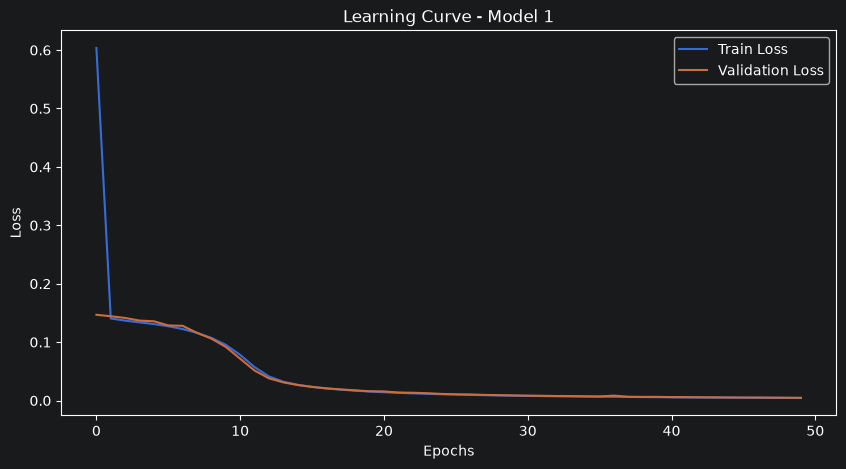

In [416]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses1, label='Train Loss')
plt.plot(val_losses1, label='Validation Loss')
plt.title('Learning Curve - Model 1')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Radi dalje optimizacije, testiramo model korišćenjem Huberove loss funkcije umesto MSE-a. Huber loss je robustnija alternativa jer kombinuje svojstva kvadratne greške za male vrednosti i apsolutne greške za velike, čineći model manje osetljivim na ekstremne vrednosti (outliers) u podacima o troškovima.

In [417]:
class CostPredictor2(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor2, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.Sigmoid(),
            nn.Linear(64, 32),
            nn.Sigmoid(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model2 = CostPredictor2(X_train.shape[1])
criterion2 = nn.HuberLoss(delta=1)
optimizer2 = optim.SGD(model2.parameters(), lr=0.01)

In [418]:
model2, train_losses2, val_losses2 = train_model(model2, train_loader, val_loader, optimizer2, criterion2, epochs=50, patience=8);

Epoch 1 , Train Loss: 0.6063 , Val Loss: 0.0814
Epoch 2 , Train Loss: 0.0721 , Val Loss: 0.0709
Epoch 3 , Train Loss: 0.0677 , Val Loss: 0.0685
Epoch 4 , Train Loss: 0.0658 , Val Loss: 0.0667
Epoch 5 , Train Loss: 0.0646 , Val Loss: 0.0656
Epoch 6 , Train Loss: 0.0637 , Val Loss: 0.0650
Epoch 7 , Train Loss: 0.0628 , Val Loss: 0.0640
Epoch 8 , Train Loss: 0.0621 , Val Loss: 0.0632
Epoch 9 , Train Loss: 0.0612 , Val Loss: 0.0623
Epoch 10 , Train Loss: 0.0603 , Val Loss: 0.0615
Epoch 11 , Train Loss: 0.0592 , Val Loss: 0.0601
Epoch 12 , Train Loss: 0.0578 , Val Loss: 0.0593
Epoch 13 , Train Loss: 0.0560 , Val Loss: 0.0564
Epoch 14 , Train Loss: 0.0535 , Val Loss: 0.0536
Epoch 15 , Train Loss: 0.0503 , Val Loss: 0.0499
Epoch 16 , Train Loss: 0.0462 , Val Loss: 0.0453
Epoch 17 , Train Loss: 0.0414 , Val Loss: 0.0404
Epoch 18 , Train Loss: 0.0362 , Val Loss: 0.0351
Epoch 19 , Train Loss: 0.0312 , Val Loss: 0.0302
Epoch 20 , Train Loss: 0.0267 , Val Loss: 0.0262
Epoch 21 , Train Loss: 0.0231

In [419]:
print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model2, val_loader)


Evaluating on Validation Set:
  MSE : 21321.3496
  RMSE: 146.0183
  MAE : 62.9938
  R2  : 0.9940
  MAPE: 6.4340%


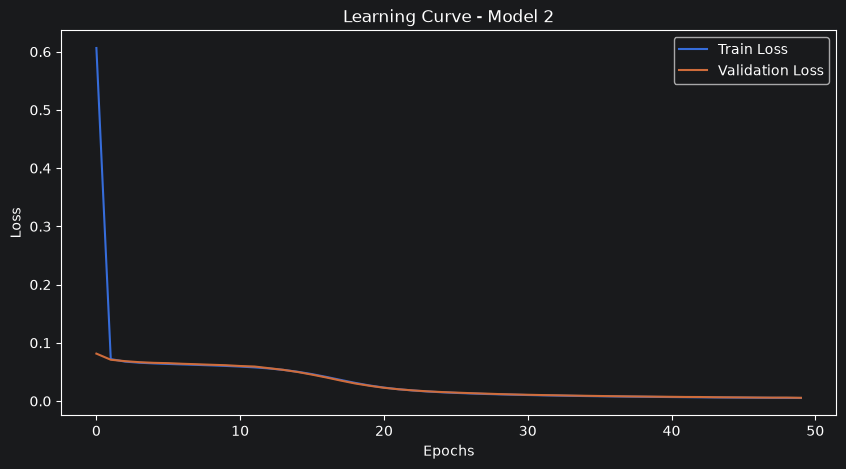

In [420]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses2, label='Train Loss')
plt.plot(val_losses2, label='Validation Loss')
plt.title('Learning Curve - Model 2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Analiza grafika učenja pokazala je da model sa Huber loss funkcijom konvergira sporije i postiže slabije rezultate u poređenju sa MSE, zbog čega zadržavamo MSE funkciju. U cilju daljeg poboljšanja performansi, zamenjujemo postojeće sigmoidne aktivacione funkcije sa ReLU funkcijom. Ona je popularna opcija u dubokom učenju jer između ostalog rešava problem vanishing gradient-a, čime se omogućava brže i stabilnije treniranje dubljih neuronskih mreža.

In [421]:
class CostPredictor3(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor3, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model3 = CostPredictor3(X_train.shape[1])
criterion3 = nn.MSELoss()
optimizer3 = optim.SGD(model3.parameters(), lr=0.01)

In [422]:
model3, train_losses3, val_losses3 = train_model(model3, train_loader, val_loader, optimizer3, criterion3, epochs=50, patience=8);

Epoch 1 , Train Loss: 0.2455 , Val Loss: 0.0320
Epoch 2 , Train Loss: 0.0209 , Val Loss: 0.0163
Epoch 3 , Train Loss: 0.0124 , Val Loss: 0.0118
Epoch 4 , Train Loss: 0.0089 , Val Loss: 0.0083
Epoch 5 , Train Loss: 0.0068 , Val Loss: 0.0070
Epoch 6 , Train Loss: 0.0054 , Val Loss: 0.0053
Epoch 7 , Train Loss: 0.0045 , Val Loss: 0.0049
Epoch 8 , Train Loss: 0.0038 , Val Loss: 0.0037
Epoch 9 , Train Loss: 0.0033 , Val Loss: 0.0033
Epoch 10 , Train Loss: 0.0029 , Val Loss: 0.0029
Epoch 11 , Train Loss: 0.0026 , Val Loss: 0.0026
Epoch 12 , Train Loss: 0.0023 , Val Loss: 0.0023
Epoch 13 , Train Loss: 0.0021 , Val Loss: 0.0022
Epoch 14 , Train Loss: 0.0019 , Val Loss: 0.0019
Epoch 15 , Train Loss: 0.0018 , Val Loss: 0.0019
Epoch 16 , Train Loss: 0.0017 , Val Loss: 0.0018
Epoch 17 , Train Loss: 0.0016 , Val Loss: 0.0017
Epoch 18 , Train Loss: 0.0014 , Val Loss: 0.0015
Epoch 19 , Train Loss: 0.0014 , Val Loss: 0.0014
Epoch 20 , Train Loss: 0.0013 , Val Loss: 0.0014
Epoch 21 , Train Loss: 0.0012

In [423]:
print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model3, val_loader)


Evaluating on Validation Set:
  MSE : 899.3333
  RMSE: 29.9889
  MAE : 15.0098
  R2  : 0.9997
  MAPE: 1.4817%


ReLU arhitektura je postigla značajno bolje rezultate. Kao sledeći korak, testiramo model sa tanh (hiperbolički tangens) aktivacionom funkcijom. Iako tanh, za razliku od ReLU, nije otporna na problem zasićenja gradijenta, ona centrira izlaze oko nule, što u određenim slučajevima može dovesti do bržeg konvergiranja i stabilnije optimizacije težina.

In [424]:
class CostPredictor4(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor4, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model4 = CostPredictor4(X_train.shape[1])
criterion4 = nn.MSELoss()
optimizer4 = optim.SGD(model4.parameters(), lr=0.01)

In [425]:
model4, train_losses4, val_losses4 = train_model(model4, train_loader, val_loader, optimizer4, criterion4, epochs=50, patience=8);

Epoch 1 , Train Loss: 0.2078 , Val Loss: 0.0437
Epoch 2 , Train Loss: 0.0305 , Val Loss: 0.0248
Epoch 3 , Train Loss: 0.0179 , Val Loss: 0.0150
Epoch 4 , Train Loss: 0.0109 , Val Loss: 0.0093
Epoch 5 , Train Loss: 0.0076 , Val Loss: 0.0069
Epoch 6 , Train Loss: 0.0059 , Val Loss: 0.0062
Epoch 7 , Train Loss: 0.0049 , Val Loss: 0.0048
Epoch 8 , Train Loss: 0.0041 , Val Loss: 0.0041
Epoch 9 , Train Loss: 0.0035 , Val Loss: 0.0036
Epoch 10 , Train Loss: 0.0031 , Val Loss: 0.0031
Epoch 11 , Train Loss: 0.0027 , Val Loss: 0.0036
Epoch 12 , Train Loss: 0.0025 , Val Loss: 0.0025
Epoch 13 , Train Loss: 0.0022 , Val Loss: 0.0027
Epoch 14 , Train Loss: 0.0020 , Val Loss: 0.0021
Epoch 15 , Train Loss: 0.0019 , Val Loss: 0.0021
Epoch 16 , Train Loss: 0.0017 , Val Loss: 0.0019
Epoch 17 , Train Loss: 0.0016 , Val Loss: 0.0017
Epoch 18 , Train Loss: 0.0015 , Val Loss: 0.0015
Epoch 19 , Train Loss: 0.0015 , Val Loss: 0.0015
Epoch 20 , Train Loss: 0.0014 , Val Loss: 0.0014
Epoch 21 , Train Loss: 0.0013

In [426]:
print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model4, val_loader)


Evaluating on Validation Set:
  MSE : 665.2836
  RMSE: 25.7931
  MAE : 12.2276
  R2  : 0.9998
  MAPE: 1.3796%


Model sa tanh aktivacionim funkcijama dao je najbolje rezultate. Međutim, posmatranjem krive gubitka uočeno je osciliranje i preskakanje minimuma funkcije, što ukazuje na to da fiksni learning rate SGD optimizatora možda nije optimalan. Kao rešenje, prelazimo na Adam optimizator, koji primenjuje adaptivnu stopu učenja za svaki parametar posebno.

In [427]:
class CostPredictor5(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor5, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model5 = CostPredictor5(X_train.shape[1])
criterion5 = nn.MSELoss()
optimizer5 = optim.Adam(model5.parameters(), lr=0.001)

In [428]:
model5, train_losses5, val_losses5 = train_model(model5, train_loader, val_loader, optimizer5, criterion5, epochs=50, patience=8);

Epoch 1 , Train Loss: 0.9172 , Val Loss: 0.0148
Epoch 2 , Train Loss: 0.0086 , Val Loss: 0.0075
Epoch 3 , Train Loss: 0.0042 , Val Loss: 0.0048
Epoch 4 , Train Loss: 0.0030 , Val Loss: 0.0028
Epoch 5 , Train Loss: 0.0025 , Val Loss: 0.0020
Epoch 6 , Train Loss: 0.0024 , Val Loss: 0.0015
Epoch 7 , Train Loss: 0.0021 , Val Loss: 0.0025
Epoch 8 , Train Loss: 0.0018 , Val Loss: 0.0016
Epoch 9 , Train Loss: 0.0018 , Val Loss: 0.0012
Epoch 10 , Train Loss: 0.0018 , Val Loss: 0.0008
Epoch 11 , Train Loss: 0.0015 , Val Loss: 0.0025
Epoch 12 , Train Loss: 0.0016 , Val Loss: 0.0006
Epoch 13 , Train Loss: 0.0014 , Val Loss: 0.0009
Epoch 14 , Train Loss: 0.0015 , Val Loss: 0.0006
Epoch 15 , Train Loss: 0.0013 , Val Loss: 0.0007
Epoch 16 , Train Loss: 0.0014 , Val Loss: 0.0004
Epoch 17 , Train Loss: 0.0012 , Val Loss: 0.0019
Epoch 18 , Train Loss: 0.0013 , Val Loss: 0.0004
Epoch 19 , Train Loss: 0.0012 , Val Loss: 0.0015
Epoch 20 , Train Loss: 0.0011 , Val Loss: 0.0024
Epoch 21 , Train Loss: 0.0013

In [429]:
print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model5, val_loader)


Evaluating on Validation Set:
  MSE : 900.4091
  RMSE: 30.0068
  MAE : 13.1324
  R2  : 0.9997
  MAPE: 1.2048%


Eksperimentalna poređenja pokazala su da konfiguracija sa tanh aktivacijom i SGD optimizatorom (fiksni learning rate) trenutno daje najstabilnije i najpreciznije rezultate. Za svaki slučaj, povećali smo kapacitet mreže proširenjem skrivenog sloja na 128 neurona kako bismo omogućili modeliranje kompleksnijih zavisnosti. Inicijalno smo testirali i Dropout sloj radi regularizacije, međutim, on je uklonjen iz finalne arhitekture jer je dovodio do underfitting-a.

In [430]:
class CostPredictor6(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor6, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.Tanh(),
            #nn.Dropout(0.4),
            nn.Linear(128, 32),    
            nn.Tanh(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)


model6 = CostPredictor6(X_train.shape[1])
criterion6 = nn.MSELoss()
optimizer6 = optim.Adam(model6.parameters(), lr=0.001)

In [431]:
model6, train_losses6, val_losses6 = train_model(model6, train_loader, val_loader, optimizer6, criterion6, epochs=50, patience=8);

Epoch 1 , Train Loss: 0.7345 , Val Loss: 0.0125
Epoch 2 , Train Loss: 0.0065 , Val Loss: 0.0039
Epoch 3 , Train Loss: 0.0043 , Val Loss: 0.0027
Epoch 4 , Train Loss: 0.0036 , Val Loss: 0.0019
Epoch 5 , Train Loss: 0.0031 , Val Loss: 0.0046
Epoch 6 , Train Loss: 0.0029 , Val Loss: 0.0022
Epoch 7 , Train Loss: 0.0026 , Val Loss: 0.0023
Epoch 8 , Train Loss: 0.0024 , Val Loss: 0.0030
Epoch 9 , Train Loss: 0.0022 , Val Loss: 0.0013
Epoch 10 , Train Loss: 0.0023 , Val Loss: 0.0011
Epoch 11 , Train Loss: 0.0018 , Val Loss: 0.0025
Epoch 12 , Train Loss: 0.0020 , Val Loss: 0.0011
Epoch 13 , Train Loss: 0.0019 , Val Loss: 0.0033
Epoch 14 , Train Loss: 0.0017 , Val Loss: 0.0011
Epoch 15 , Train Loss: 0.0017 , Val Loss: 0.0017
Epoch 16 , Train Loss: 0.0015 , Val Loss: 0.0027
Epoch 17 , Train Loss: 0.0015 , Val Loss: 0.0023
Epoch 18 , Train Loss: 0.0015 , Val Loss: 0.0007
Epoch 19 , Train Loss: 0.0014 , Val Loss: 0.0031
Epoch 20 , Train Loss: 0.0014 , Val Loss: 0.0009
Epoch 21 , Train Loss: 0.0013

In [432]:
print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model6, val_loader)


Evaluating on Validation Set:
  MSE : 1153.1116
  RMSE: 33.9575
  MAE : 14.6042
  R2  : 0.9997
  MAPE: 1.2737%


Model 4 (tanh + SGD) je i dalje najefikasniji u dosadašnjim eksperimentima. U cilju daljeg finog podešavanja i postizanja boljih performansi, uveli smo ReduceLROnPlateau scheduler koji dinamički menja learning rate kada validacioni loss stagnira. Pored toga, povećali smo ukupan broj epoha, što modelu omogućava duži proces konvergencije.

In [433]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

class CostPredictor7(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor7, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model7 = CostPredictor7(X_train.shape[1])
criterion7 = nn.MSELoss()
optimizer7 = optim.SGD(model7.parameters(), lr=0.01)
scheduler7 = ReduceLROnPlateau(optimizer7, mode='min', factor=0.1, patience=5, threshold=0.01, 
    threshold_mode='rel')


In [434]:
device = "cpu"

model7.to(device)
best_val_loss = float('inf')
trigger_count = 0
best_model_state = None
 
train_losses = []
val_losses = []

epochs = 150
patience = 10

for epoch in range(epochs):
    model7.train()
    epoch_train_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
         
        optimizer7.zero_grad()
        outputs = model7(batch_X)
        loss = criterion7(outputs.squeeze(), batch_y)
        loss.backward()
        optimizer7.step()
        epoch_train_loss += loss.item()
     
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
     
    model7.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model7(batch_X)
            epoch_val_loss += criterion7(outputs.squeeze(), batch_y).item()
     
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
     
    print(f"Epoch {epoch+1} , Train Loss: {avg_train_loss:.4f} , Val Loss: {avg_val_loss:.4f} , LR: {optimizer7.param_groups[0]['lr']:.6f}")
    scheduler7.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        trigger_count = 0
        best_model_state = copy.deepcopy(model7.state_dict())
    else:
        trigger_count += 1
        if trigger_count >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

if best_model_state is not None:
    model7.load_state_dict(best_model_state)

Epoch 1 , Train Loss: 0.2118 , Val Loss: 0.0405 , LR: 0.010000
Epoch 2 , Train Loss: 0.0305 , Val Loss: 0.0230 , LR: 0.010000
Epoch 3 , Train Loss: 0.0160 , Val Loss: 0.0130 , LR: 0.010000
Epoch 4 , Train Loss: 0.0107 , Val Loss: 0.0100 , LR: 0.010000
Epoch 5 , Train Loss: 0.0084 , Val Loss: 0.0081 , LR: 0.010000
Epoch 6 , Train Loss: 0.0070 , Val Loss: 0.0070 , LR: 0.010000
Epoch 7 , Train Loss: 0.0060 , Val Loss: 0.0059 , LR: 0.010000
Epoch 8 , Train Loss: 0.0053 , Val Loss: 0.0058 , LR: 0.010000
Epoch 9 , Train Loss: 0.0047 , Val Loss: 0.0049 , LR: 0.010000
Epoch 10 , Train Loss: 0.0042 , Val Loss: 0.0044 , LR: 0.010000
Epoch 11 , Train Loss: 0.0038 , Val Loss: 0.0039 , LR: 0.010000
Epoch 12 , Train Loss: 0.0034 , Val Loss: 0.0034 , LR: 0.010000
Epoch 13 , Train Loss: 0.0031 , Val Loss: 0.0032 , LR: 0.010000
Epoch 14 , Train Loss: 0.0029 , Val Loss: 0.0029 , LR: 0.010000
Epoch 15 , Train Loss: 0.0026 , Val Loss: 0.0027 , LR: 0.010000
Epoch 16 , Train Loss: 0.0024 , Val Loss: 0.0029 

In [435]:
print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model7, val_loader)


Evaluating on Validation Set:
  MSE : 283.8761
  RMSE: 16.8486
  MAE : 7.8292
  R2  : 0.9999
  MAPE: 0.8658%


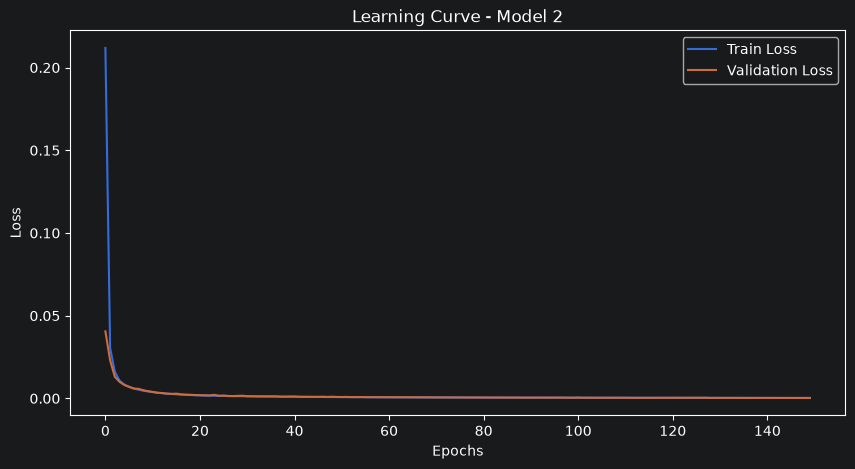

In [436]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Learning Curve - Model 2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Evaluacija

Za konačnu procenu performansi koristimo test set koji do sada nismo koristili u procesu treniranja niti validacije. Ovim osiguravamo nepristrasnu procenu sposobnosti modela da generalizuje na potpuno nove podatke, eliminišući rizik od „data leakage“ i potvrđujući njegovu stvarnu primenljivost u produkcionom okruženju.

In [437]:
print("\nEvaluating on Test Set:")
val_results = evaluate_regression_model(model7, test_loader)


Evaluating on Test Set:
  MSE : 303.1140
  RMSE: 17.4102
  MAE : 7.7800
  R2  : 0.9999
  MAPE: 0.8486%


Konačni rezultati evaluacije na testnom setu potvrđuju odlične performanse modela. R² skor od 0.9997 ukazuje na gotovo savršeno prilagođavanje podacima, dok MAPE od 1.7178% potvrđuje visoku preciznost. Mala razlika između RMSE i MAE metrika dodatno ukazuje na robusnost modela i odsustvo značajnog uticaja ekstremnih vrednosti (outliers), što ovaj model čini izuzetno pouzdanim alatom za precizno predviđanje budućih troškova.